# Лабораторна 10 — Аналітика GeoAI: Spatial CV + SHAP

Цей ноутбук — **дослідницька частина** лабораторної.
Django-додаток запускається окремо через Docker.

Кроки:
1. Отримати реальні POI Лісабону з Overpass API
2. Побудувати просторові ознаки
3. Spatial Blocked Cross-Validation (запобігає autocorrelation bias)
4. Random Forest + важливість ознак
5. SHAP аналіз по класах
6. Зберегти модель для Django

## 0. Імпорти

In [1]:
import math
import time
import requests
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from shapely.geometry import Point
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, classification_report,
                              ConfusionMatrixDisplay, confusion_matrix)
import shap
import joblib

print('Всі пакети імпортовано')

Всі пакети імпортовано


## 1. Завантаження даних з Overpass API (OpenStreetMap)

In [2]:
OVERPASS_URL = 'https://overpass-api.de/api/interpreter'
BBOX = '38.65,-9.25,38.80,-9.05'  # Lisbon bbox

CATEGORIES = {
    'hospital': 'hospital',
    'school': 'school',
    'cafe': 'cafe',
    'pharmacy': 'pharmacy',
    'police': 'police',
    'fire_station': 'fire_station',
    'parking': 'parking',
}

records = []
for amenity, category in CATEGORIES.items():
    query = f'[out:json][timeout:30];node[amenity={amenity}]({BBOX});out body;'
    try:
        resp = requests.get(
            OVERPASS_URL,
            params={'data': query},
            timeout=35,
            headers={'User-Agent': 'GeoDjango-Lab10/1.0 (student project)'}
        )
        resp.raise_for_status()
        data_j = resp.json()
        elements = data_j.get('elements', [])
        for el in elements:
            if el.get('type') != 'node':
                continue
            records.append({
                'osm_id':   el['id'],
                'name':     el.get('tags', {}).get('name', ''),
                'category': category,
                'lat':      el['lat'],
                'lon':      el['lon'],
            })
        print(f'  {category:15s}: {len(elements):4d} POI')
        time.sleep(1)
    except Exception as e:
        print(f'  {category}: ПОМИЛКА — {e}')

# Fallback: якщо Overpass недоступний — генеруємо синтетичні дані для Лісабону
if len(records) < 50:
    print('\nOverpass недоступний — генеруємо синтетичні дані (Lisbon-like)...')
    rng = np.random.default_rng(42)
    CENTER_LAT_F, CENTER_LON_F = 38.7169, -9.1393
    SYNTH_N = {'hospital':25, 'school':60, 'cafe':200, 'pharmacy':50,
               'police':15, 'fire_station':10, 'parking':90}
    synth_id = 1
    for cat, n in SYNTH_N.items():
        for _ in range(n):
            lat = CENTER_LAT_F + rng.uniform(-0.04, 0.04)
            lon = CENTER_LON_F + rng.uniform(-0.06, 0.06)
            records.append({'osm_id': synth_id, 'name': f'{cat}_{synth_id}',
                            'category': cat, 'lat': lat, 'lon': lon})
            synth_id += 1
    print(f'Згенеровано {len(records)} синтетичних POI (демонстраційні дані)')

df_raw = pd.DataFrame(records)
gdf = gpd.GeoDataFrame(
    df_raw,
    geometry=gpd.points_from_xy(df_raw['lon'], df_raw['lat']),
    crs='EPSG:4326'
)
print(f'\nВсього: {len(gdf)} POI')
print(gdf['category'].value_counts().to_string())

  hospital       :   10 POI


  school         :  126 POI


  cafe           : 1580 POI


  pharmacy       :  426 POI


  police         :   47 POI


  fire_station   :    9 POI


  parking        :  422 POI



Всього: 2620 POI
category
cafe            1580
pharmacy         426
parking          422
school           126
police            47
hospital          10
fire_station       9


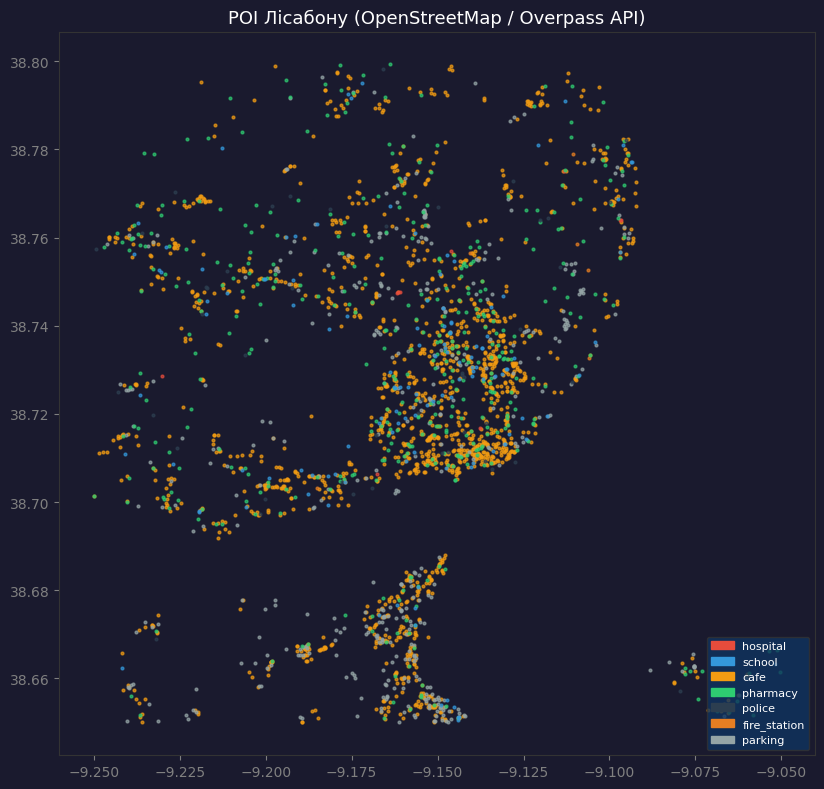

category
cafe            1580
pharmacy         426
parking          422
school           126
police            47
hospital          10
fire_station       9


In [3]:
# карта завантажених POI
COLORS = {
    'hospital':'#e74c3c', 'school':'#3498db', 'cafe':'#f39c12',
    'pharmacy':'#2ecc71', 'police':'#2c3e50', 'fire_station':'#e67e22',
    'parking':'#95a5a6'
}

fig, ax = plt.subplots(figsize=(10, 8), facecolor='#1a1a2e')
ax.set_facecolor('#1a1a2e')

for cat, grp in gdf.groupby('category'):
    grp.plot(ax=ax, color=COLORS.get(cat,'#777'), markersize=4, alpha=0.7, label=cat)

ax.set_title('POI Лісабону (OpenStreetMap / Overpass API)', color='white', fontsize=13)
ax.tick_params(colors='gray')
for spine in ax.spines.values(): spine.set_edgecolor('#333')
patches = [mpatches.Patch(color=c, label=k) for k, c in COLORS.items()]
ax.legend(handles=patches, fontsize=8, loc='lower right',
          facecolor='#0f3460', labelcolor='white', edgecolor='#333')
plt.tight_layout()
plt.savefig('poi_osm_map.png', dpi=120, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()
print(gdf['category'].value_counts().to_string())

## 2. Просторові ознаки (Feature Engineering)

In [4]:
CENTER_LAT, CENTER_LON = 38.7169, -9.1393
LAT_M = 111319.5
LON_M = 111319.5 * math.cos(math.radians(CENTER_LAT))

def dist_m(lat1, lon1, lat2, lon2):
    return math.sqrt(((lat1-lat2)*LAT_M)**2 + ((lon1-lon2)*LON_M)**2)

# відстань від центру міста
gdf['dist_center_m'] = gdf.apply(
    lambda r: dist_m(r.lat, r.lon, CENTER_LAT, CENTER_LON), axis=1
)

# кількість POI у радіусі 500м
gdf_m = gdf.to_crs('EPSG:3763')
def count_near(gdf_local, radius):
    counts = []
    for geom in gdf_local.geometry:
        buf = geom.buffer(radius)
        counts.append(int(gdf_local.geometry.within(buf).sum()) - 1)
    return np.array(counts)

gdf['poi_500m'] = count_near(gdf_m, 500)

# відстань до найближчих екстрених служб
hosp  = gdf[gdf.category=='hospital'][['lat','lon']].values
pol   = gdf[gdf.category=='police'][['lat','lon']].values
fire  = gdf[gdf.category=='fire_station'][['lat','lon']].values

def min_dist_to_targets(lat, lon, targets, default=5000.0):
    if len(targets)==0: return default
    return min(dist_m(lat,lon,t[0],t[1]) for t in targets)

gdf['hosp_500m']    = gdf.apply(
    lambda r: sum(1 for t in hosp if dist_m(r.lat,r.lon,t[0],t[1]) < 500), axis=1)
gdf['dist_hosp_m']  = gdf.apply(
    lambda r: min_dist_to_targets(r.lat,r.lon,hosp), axis=1)
gdf['dist_police_m']= gdf.apply(
    lambda r: min_dist_to_targets(r.lat,r.lon,pol), axis=1)
gdf['dist_fire_m']  = gdf.apply(
    lambda r: min_dist_to_targets(r.lat,r.lon,fire), axis=1)

FEATURES = ['dist_center_m','poi_500m','hosp_500m','dist_hosp_m','dist_police_m','dist_fire_m']
FEAT_LABELS = ['Відст. центру', 'POI 500м', 'Лікарні 500м',
               'До лікарні', 'До поліції', 'До пожежних']

print('Ознаки обчислено:')
print(gdf[FEATURES].describe().round(1).to_string())

Ознаки обчислено:
       dist_center_m  poi_500m  hosp_500m  dist_hosp_m  dist_police_m  dist_fire_m
count         2620.0    2620.0     2620.0       2620.0         2620.0       2620.0
mean          4701.0      31.7        0.1       2516.9         1349.5       2355.4
std           2832.5      23.7        0.3       1893.7         1410.6       1900.3
min            113.8       0.0        0.0          0.0            0.0          0.0
25%           1952.4      13.0        0.0       1157.3          425.5        995.3
50%           4693.3      26.0        0.0       1886.8          825.2       1636.6
75%           7027.5      45.0        0.0       3360.7         1606.2       3465.2
max          11474.2     113.0        3.0       9987.4         6094.7       9846.5


## 3. Синтетичний цільовий показник (Risk Level)

Розподіл Risk Level:
risk
Low       1771
Medium     570
High       279
Name: count, dtype: int64


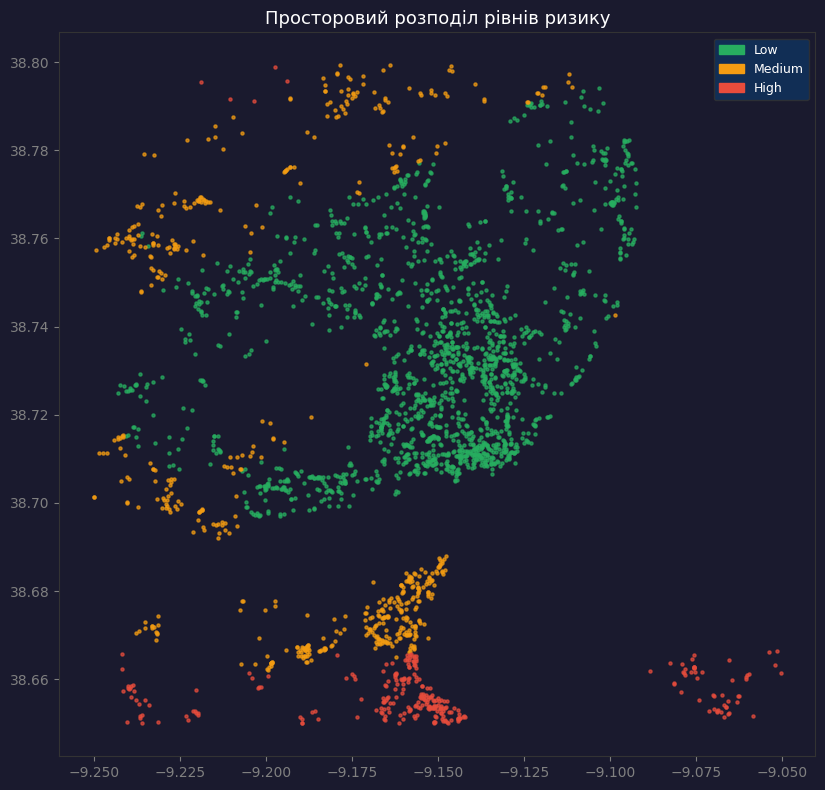

In [5]:
# Risk = зважена доступність екстрених служб
# (в реальному проєкті: реальні дані про ДТП/злочини/пожежі)
score = (
    gdf['dist_hosp_m']   / gdf['dist_hosp_m'].max()   * 0.40
  + gdf['dist_police_m'] / gdf['dist_police_m'].max() * 0.30
  + gdf['dist_fire_m']   / gdf['dist_fire_m'].max()   * 0.20
  + (1 - gdf['poi_500m'] / (gdf['poi_500m'].max()+1)) * 0.10
)

gdf['risk'] = pd.cut(score, bins=3, labels=['Low','Medium','High'])
gdf = gdf.dropna(subset=['risk'])

print('Розподіл Risk Level:')
print(gdf['risk'].value_counts())

# карта ризику
risk_colors = {'Low':'#27ae60', 'Medium':'#f39c12', 'High':'#e74c3c'}
fig, ax = plt.subplots(figsize=(10, 8), facecolor='#1a1a2e')
ax.set_facecolor('#1a1a2e')
for risk, grp in gdf.groupby('risk'):
    grp.plot(ax=ax, color=risk_colors[risk], markersize=5, alpha=0.7, label=risk)
ax.set_title('Просторовий розподіл рівнів ризику', color='white', fontsize=13)
ax.tick_params(colors='gray')
for spine in ax.spines.values(): spine.set_edgecolor('#333')
patches = [mpatches.Patch(color=c, label=k) for k,c in risk_colors.items()]
ax.legend(handles=patches, fontsize=9, facecolor='#0f3460', labelcolor='white', edgecolor='#333')
plt.tight_layout()
plt.savefig('risk_map.png', dpi=120, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()

## 4. Spatial Blocked Cross-Validation

=== Spatial Blocked CV (5 lat-блоків) ===
Accuracy per block: [0.4604, 0.9636, 0.9478, 0.9806, 0.9394]
Mean: 0.8584  Std: 0.1995


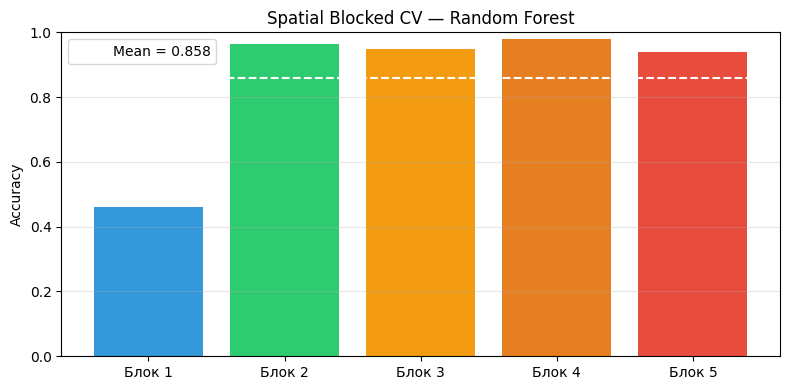

In [6]:
le = LabelEncoder()
X  = gdf[FEATURES].values
y  = le.fit_transform(gdf['risk'])
coords = gdf[['lat','lon']].values

def spatial_blocked_cv(X, y, coords, n_blocks=5):
    lats = coords[:,0]
    q = np.linspace(lats.min(), lats.max(), n_blocks+1)
    folds, scores = [], []
    for i in range(n_blocks):
        test_mask = (lats >= q[i]) & (lats <= q[i+1])
        tr_idx = np.where(~test_mask)[0]
        te_idx = np.where(test_mask)[0]
        if len(te_idx)==0 or len(tr_idx)==0: continue
        rf_cv = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42, n_jobs=-1)
        rf_cv.fit(X[tr_idx], y[tr_idx])
        acc = accuracy_score(y[te_idx], rf_cv.predict(X[te_idx]))
        scores.append(acc)
        folds.append((i, len(tr_idx), len(te_idx), acc))
    return scores, folds

cv_scores, folds_info = spatial_blocked_cv(X, y, coords, n_blocks=5)

print('=== Spatial Blocked CV (5 lat-блоків) ===')
print(f'Accuracy per block: {[round(s,4) for s in cv_scores]}')
print(f'Mean: {np.mean(cv_scores):.4f}  Std: {np.std(cv_scores):.4f}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(len(cv_scores)), cv_scores,
       color=['#3498db','#2ecc71','#f39c12','#e67e22','#e74c3c'][:len(cv_scores)])
ax.axhline(np.mean(cv_scores), color='white', ls='--', lw=1.5,
           label=f'Mean = {np.mean(cv_scores):.3f}')
ax.set_xticks(range(len(cv_scores)))
ax.set_xticklabels([f'Блок {i+1}' for i in range(len(cv_scores))])
ax.set_ylabel('Accuracy'); ax.set_ylim(0, 1)
ax.set_title('Spatial Blocked CV — Random Forest')
ax.legend(); ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('spatial_cv.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. Фінальна модель Random Forest

Test Accuracy: 0.9817

              precision    recall  f1-score   support

        High       1.00      0.97      0.99        70
         Low       0.98      1.00      0.99       443
      Medium       0.97      0.94      0.96       142

    accuracy                           0.98       655
   macro avg       0.98      0.97      0.98       655
weighted avg       0.98      0.98      0.98       655



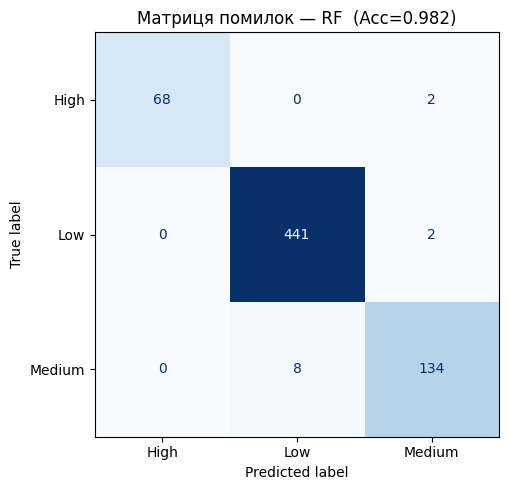

In [7]:
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

rf = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1)
rf.fit(X_tr, y_tr)
y_pred = rf.predict(X_te)
acc = accuracy_score(y_te, y_pred)

print(f'Test Accuracy: {acc:.4f}')
print()
print(classification_report(y_te, y_pred, target_names=le.classes_))

# Confusion matrix
cm = confusion_matrix(y_te, y_pred)
fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(
    ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Матриця помилок — RF  (Acc={acc:.3f})')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

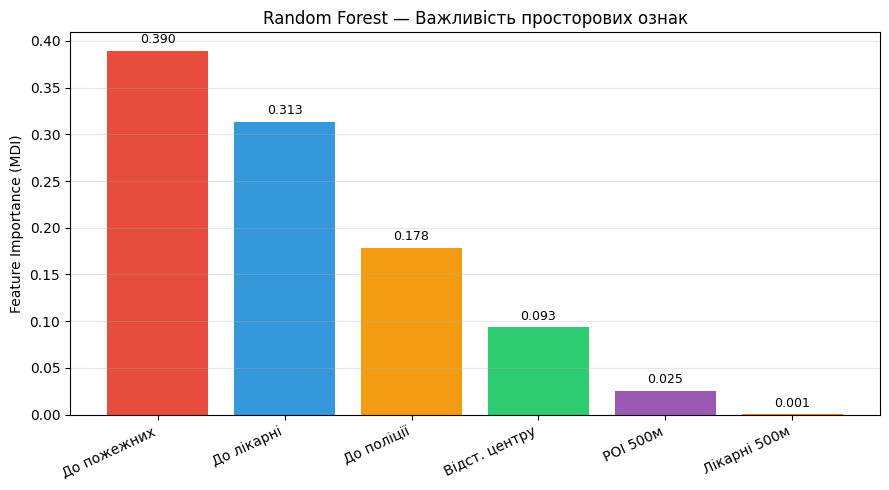

In [8]:
# Feature importance
importances = rf.feature_importances_
sorted_idx = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(9, 5))
bar_colors = ['#e74c3c','#3498db','#f39c12','#2ecc71','#9b59b6','#e67e22']
ax.bar(range(len(importances)), importances[sorted_idx],
       color=[bar_colors[i] for i in range(len(importances))])
ax.set_xticks(range(len(importances)))
ax.set_xticklabels([FEAT_LABELS[i] for i in sorted_idx], rotation=25, ha='right')
ax.set_ylabel('Feature Importance (MDI)')
ax.set_title('Random Forest — Важливість просторових ознак')
for j, (idx, imp) in enumerate(zip(sorted_idx, importances[sorted_idx])):
    ax.text(j, imp + 0.005, f'{imp:.3f}', ha='center', va='bottom', fontsize=9)
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. SHAP — пояснення моделі (GeoXAI)

In [9]:
explainer  = shap.TreeExplainer(rf)
X_sample   = X_te[:150]
shap_raw   = explainer.shap_values(X_sample)

# нові версії shap → 3D (n_samples, n_feats, n_classes)
# старі → list[n_classes]
if isinstance(shap_raw, list):
    sv_list = shap_raw
else:
    sv_list = [shap_raw[:,:,i] for i in range(shap_raw.shape[2])]

n_cls = len(le.classes_)
print(f'Класи: {le.classes_}')
print(f'SHAP shape per class: {sv_list[0].shape}')

Класи: ['High' 'Low' 'Medium']
SHAP shape per class: (150, 6)


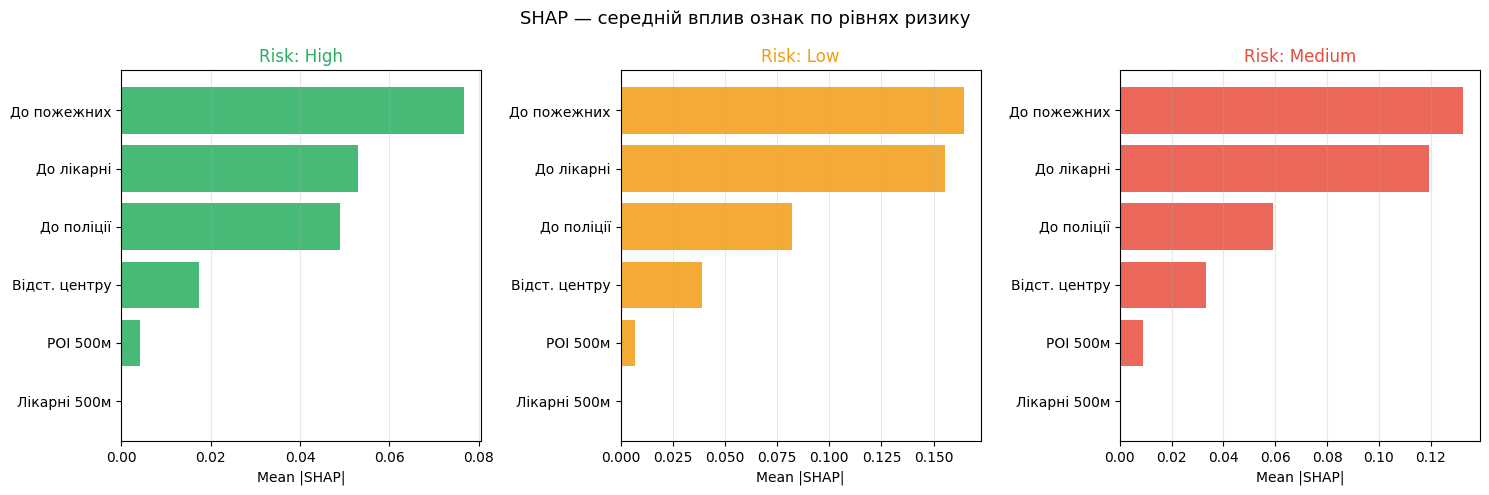

In [10]:
# SHAP Bar — mean |SHAP| по класах
fig, axes = plt.subplots(1, n_cls, figsize=(5*n_cls, 5))
cls_colors = ['#27ae60', '#f39c12', '#e74c3c']

for i, cls_name in enumerate(le.classes_):
    mean_abs = np.abs(sv_list[i]).mean(axis=0)
    sorted_s = np.argsort(mean_abs)
    axes[i].barh([FEAT_LABELS[j] for j in sorted_s], mean_abs[sorted_s],
                  color=cls_colors[i], alpha=0.85)
    axes[i].set_title(f'Risk: {cls_name}', fontsize=12, color=cls_colors[i])
    axes[i].set_xlabel('Mean |SHAP|')
    axes[i].grid(alpha=0.3, axis='x')

plt.suptitle('SHAP — середній вплив ознак по рівнях ризику', fontsize=13)
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=120, bbox_inches='tight')
plt.show()

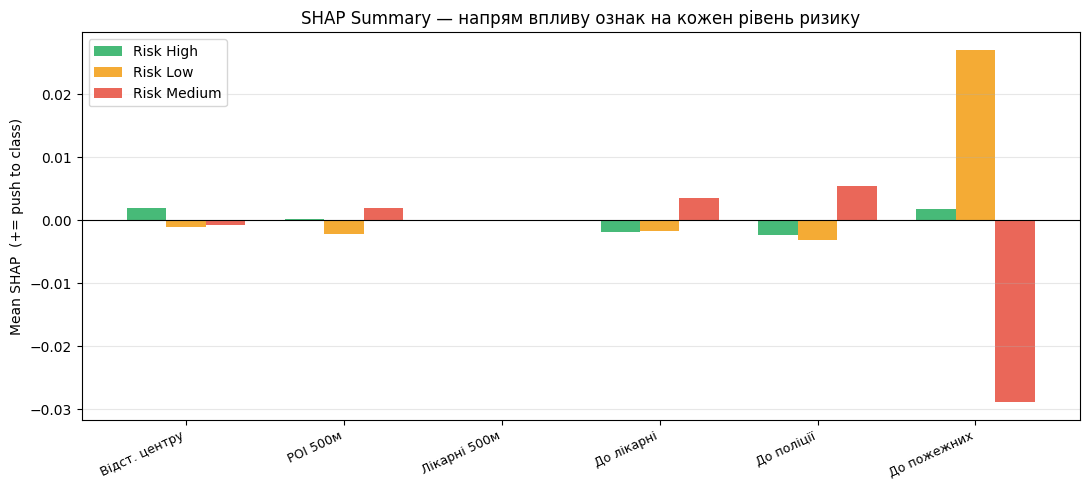

In [11]:
# SHAP Summary (grouped bar) — знак SHAP
fig, ax = plt.subplots(figsize=(11, 5))
x   = np.arange(len(FEATURES))
w   = 0.25

for i, (cls_name, color) in enumerate(zip(le.classes_, cls_colors)):
    mean_shap = sv_list[i].mean(axis=0)
    ax.bar(x + i*w, mean_shap, w, label=f'Risk {cls_name}', color=color, alpha=0.85)

ax.set_xticks(x + w)
ax.set_xticklabels(FEAT_LABELS, rotation=25, ha='right', fontsize=9)
ax.set_ylabel('Mean SHAP  (+= push to class)')
ax.set_title('SHAP Summary — напрям впливу ознак на кожен рівень ризику')
ax.axhline(0, color='black', lw=0.8)
ax.legend(); ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=120, bbox_inches='tight')
plt.show()

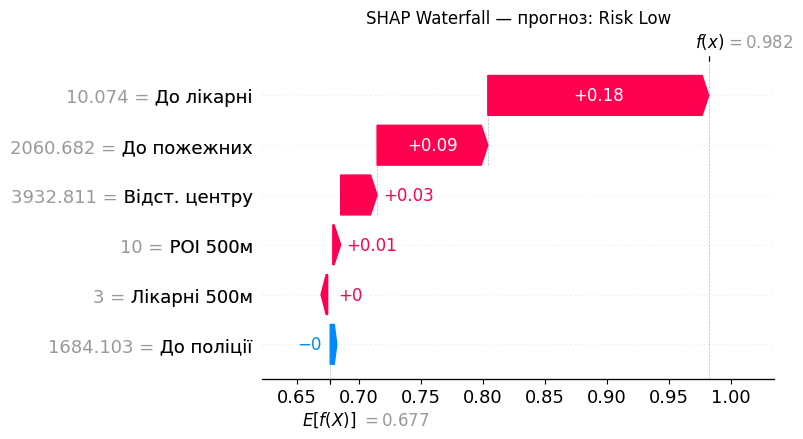

Зразок: Risk Low (confidence 0.982)


In [12]:
# SHAP Waterfall для одного прикладу
sample_idx   = 0
pred_cls_idx = int(rf.predict(X_sample[[sample_idx]])[0])
pred_cls     = le.classes_[pred_cls_idx]

base_val = (explainer.expected_value[pred_cls_idx]
            if hasattr(explainer.expected_value, '__len__')
            else explainer.expected_value)

exp = shap.Explanation(
    values=sv_list[pred_cls_idx][sample_idx],
    base_values=base_val,
    data=X_sample[sample_idx],
    feature_names=FEAT_LABELS
)

plt.figure(figsize=(10, 5))
shap.plots.waterfall(exp, show=False)
plt.title(f'SHAP Waterfall — прогноз: Risk {pred_cls}', fontsize=12)
plt.tight_layout()
plt.savefig('shap_waterfall.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Зразок: Risk {pred_cls} (confidence {rf.predict_proba(X_sample[[sample_idx]])[0].max():.3f})')

## 7. Зберігаємо модель для Django

In [13]:
from pathlib import Path

ML_DIR = Path('ml')
ML_DIR.mkdir(exist_ok=True)

joblib.dump(rf,       ML_DIR / 'rf_model.joblib')
joblib.dump(le,       ML_DIR / 'label_encoder.joblib')
joblib.dump(FEATURES, ML_DIR / 'feature_names.joblib')

size_kb = (ML_DIR / 'rf_model.joblib').stat().st_size // 1024
print(f'rf_model.joblib:       {size_kb} KB')
print(f'label_encoder.joblib:  OK')
print(f'feature_names.joblib:  {FEATURES}')
print()
print('Модель готова. Для Django:')
print('  docker-compose exec web python manage.py import_osm')
print('  docker-compose exec web python manage.py train_model')

rf_model.joblib:       1321 KB
label_encoder.joblib:  OK
feature_names.joblib:  ['dist_center_m', 'poi_500m', 'hosp_500m', 'dist_hosp_m', 'dist_police_m', 'dist_fire_m']

Модель готова. Для Django:
  docker-compose exec web python manage.py import_osm
  docker-compose exec web python manage.py train_model


## 8. Підсумок аналізу

In [14]:
print('='*60)
print('ПІДСУМОК — ЛАБОРАТОРНА 10: GeoAI Risk Assessment')
print('='*60)
print()
print(f'Джерело даних:    Overpass API (OpenStreetMap)')
print(f'POI:              {len(gdf)} (Лісабон)')
print(f'Категорій:        {gdf.category.nunique()} ({list(gdf.category.unique())})')
print(f'Ознак (features): {len(FEATURES)}')
print()
print(f'Random Forest:    200 дерев, max_depth=8')
print(f'Test Accuracy:    {acc:.4f}')
print(f'Spatial CV:       {np.mean(cv_scores):.4f} ± {np.std(cv_scores):.4f} (5 lat-блоків)')
print()
print('SHAP TopFeature per Risk Level:')
for i, cls in enumerate(le.classes_):
    top = np.abs(sv_list[i]).mean(axis=0).argmax()
    print(f'  {cls:8s}: {FEAT_LABELS[top]}')
print()
print('Файли:')
print('  poi_osm_map.png, risk_map.png, spatial_cv.png')
print('  confusion_matrix.png, feature_importance.png')
print('  shap_bar.png, shap_summary.png, shap_waterfall.png')
print('  ml/rf_model.joblib, ml/label_encoder.joblib')
print()
print('Django сервіс:')
print('  docker-compose up --build')
print('  docker-compose exec web python manage.py import_osm')
print('  docker-compose exec web python manage.py train_model')
print('  http://localhost:8000  — карта з GeoXAI')
print('  http://localhost:8000/admin/ — OSMGeoAdmin (POI + RiskZone)')

ПІДСУМОК — ЛАБОРАТОРНА 10: GeoAI Risk Assessment

Джерело даних:    Overpass API (OpenStreetMap)
POI:              2620 (Лісабон)
Категорій:        7 (['hospital', 'school', 'cafe', 'pharmacy', 'police', 'fire_station', 'parking'])
Ознак (features): 6

Random Forest:    200 дерев, max_depth=8
Test Accuracy:    0.9817
Spatial CV:       0.8584 ± 0.1995 (5 lat-блоків)

SHAP TopFeature per Risk Level:
  High    : До пожежних
  Low     : До пожежних
  Medium  : До пожежних

Файли:
  poi_osm_map.png, risk_map.png, spatial_cv.png
  confusion_matrix.png, feature_importance.png
  shap_bar.png, shap_summary.png, shap_waterfall.png
  ml/rf_model.joblib, ml/label_encoder.joblib

Django сервіс:
  docker-compose up --build
  docker-compose exec web python manage.py import_osm
  docker-compose exec web python manage.py train_model
  http://localhost:8000  — карта з GeoXAI
  http://localhost:8000/admin/ — OSMGeoAdmin (POI + RiskZone)
